In [9]:
!uv pip install timm

Resolved 40 packages in 87ms                                         
Installed 1 package in 18ms                                 
 + timm==1.0.22


In [1]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)

In [2]:
import sys
print(sys.executable)
print(sys.version)

/home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/.venv/bin/python3
3.11.14 (main, Nov 19 2025, 22:47:14) [Clang 21.1.4 ]


In [3]:
import fastcore
import torch
from fastai.vision.all import *
from fastai.vision.widgets import *
import gc
import timm

In [4]:
import fastbook
fastbook.setup_book()

## WARNING: This section will delete model

In [5]:
del learn
gc.collect()
torch.cuda.empty_cache()

NameError: name 'learn' is not defined

In [6]:
path = Path('training_data')
def label_func(path):
    return path.parent.name

In [7]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=label_func,
    item_tfms=Resize(256),
    batch_tfms=aug_transforms(size=256, min_scale=0.75)
)

dls = dblock.dataloaders(path, bs=48)

In [8]:
learn = vision_learner(dls, 'convnext_small.fb_in22k', pretrained=True, loss_func=LabelSmoothingCrossEntropy(), metrics=[accuracy, error_rate])
learn.to_fp16()
learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.529522,0.283688,0.916292,0.083708,06:05


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.359553,0.204791,0.940369,0.059631,07:53
1,0.261597,0.162985,0.952820,0.047180,07:56
2,0.159516,0.147200,0.958146,0.041854,07:48


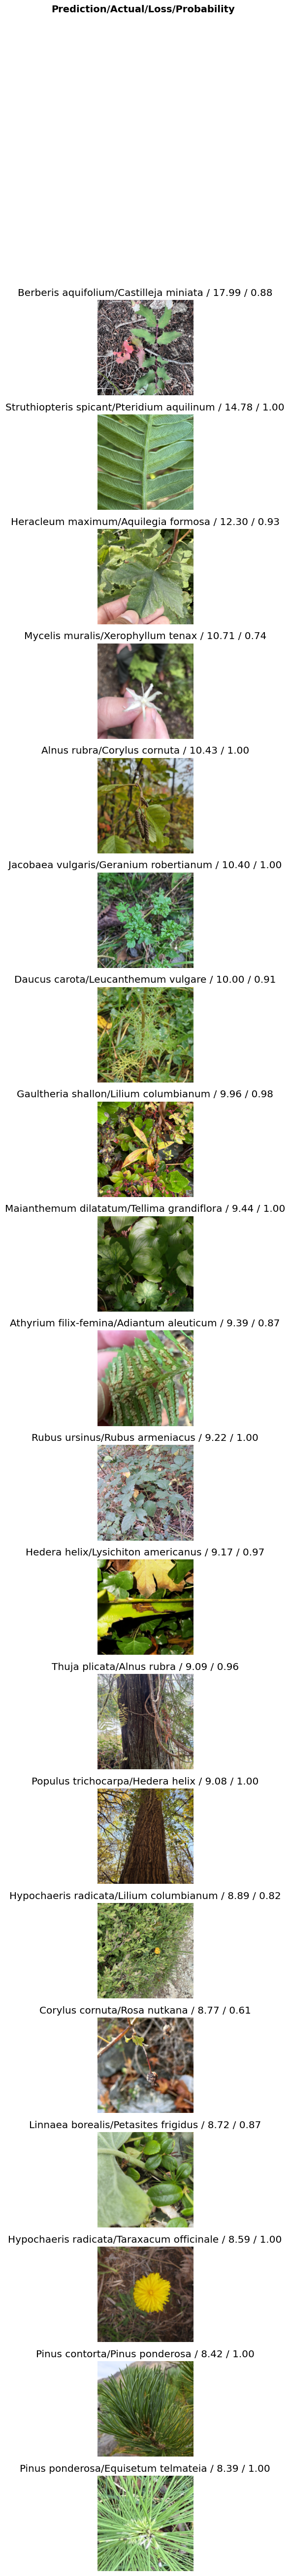

In [9]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(20, nrows=20)

In [10]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [38]:
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

In [ ]:
learn.save('plants_256_baseline')

In [ ]:
dblock_384 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=label_func,
    item_tfms=Resize(384),
    batch_tfms=aug_transforms(size=384, min_scale=0.75)
)

dls_384 = dblock_384.dataloaders(path, bs=32)

In [ ]:
learn = vision_learner(dls_384, resnet50, pretrained=False, metrics=[accuracy, error_rate])
learn.load('plants_256_baseline')

In [ ]:
learn.to_fp16()
learn.freeze()
learn.fit_one_cycle(2, 1e-3)

In [ ]:
learn.save('plants_384_baseline')

In [ ]:
interp = Interpretation.from_learner(learn)
interp.plot_top_losses(20, nrows=5)

In [ ]:
learn = vision_learner(dls_384, resnet50, pretrained=False, metrics=[accuracy, error_rate])
learn.load('plants_384_baseline')

In [ ]:
learn.to_fp16()
learn.unfreeze()
learn.fit_one_cycle(10, lr_max=slice(1e-6, 1e-4))